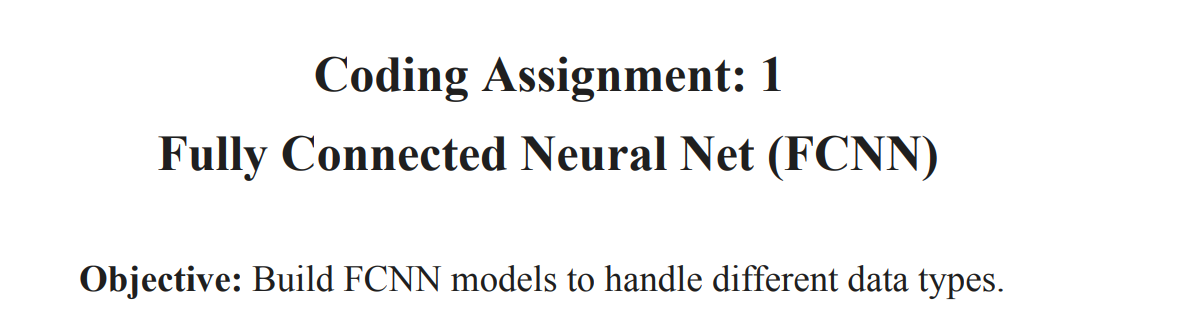

# Part 1: Tabular Modelling (Frameworks Allowed)

Goal: Model the relationship between demographic features and income level using a standard library (PyTorch)

#### Step 1: Imports and Device Setup

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Device configuration (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Data Handling: 
Load the UCI Adult Census dataset. You must process the categorical variables and handle the scale of numerical features (e.g., Age vs. Capital Gain).


#### Step 2: Load Dataset

In [3]:
# Path
path = "D:/Computer Science/IIT Mandi/Trimester 03/Datasets/adult/"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

# Load train data
train_df = pd.read_csv(f"{path}adult.data",
                       names=columns,
                       bskipinitialspace=True)

# Load test data (skip metadata row)
test_df = pd.read_csv(f"{path}adult.test",
                      names=columns,
                      skipinitialspace=True,
                      skiprows=1)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (32561, 15)
Test shape: (16281, 15)


In [5]:
# Print the first 5 rows of the training set
print("--- Training Data Sample ---")
print(train_df.head())

# Print the first 5 rows of the test set
print("\n--- Test Data Sample ---")
print(test_df.head())

--- Training Data Sample ---
   age         workclass  fnlwgt  education  education-num  \
0   39         state-gov   77516  bachelors             13   
1   50  self-emp-not-inc   83311  bachelors             13   
2   38           private  215646    hs-grad              9   
3   53           private  234721       11th              7   
4   28           private  338409  bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       never-married       adm-clerical  not-in-family  white    male   
1  married-civ-spouse    exec-managerial        husband  white    male   
2            divorced  handlers-cleaners  not-in-family  white    male   
3  married-civ-spouse  handlers-cleaners        husband  black    male   
4  married-civ-spouse     prof-specialty           wife  black  female   

   capital-gain  capital-loss  hours-per-week native-country  income  
0          2174             0              40  united-states       0  
1          

#### Observations:

1.  
The dataset contains a mixture of numerical and categorical features. Numerical features include age, fnlwgt, education-num, capital-gain, capital-loss and hours-per-week. These can be directly used for modelling, but their scale differences will have to be handled properly.

2.  
Categorical features such as workclass, education, marital-status, occupation, relationship, race, sex and native-country cannot be directly fed into a neural network. Since FCNNs only accept numerical input, these features will have to be converted into numerical representation using one-hot encoding.

3.  
Some rows contain missing values represented as '?'. Instead of removing these rows, '?' will have to be treated as a separate valid category to avoid unnecessary loss of data.

4.  
The income column contains string labels such as '<=50K' and '>50K' (with trailing '.' in the test set). These values will have to be cleaned and converted into binary format:
<=50K → 0  
>50K  → 1  
This will convert the problem into a binary classification task.

5.  
Before encoding, categorical values will have to be standardized by converting them to lowercase and removing leading or trailing spaces. This will ensure consistency across categories.

6.  
After applying one-hot encoding separately on training and test datasets, column alignment will have to be performed. This ensures both datasets have identical feature dimensions before training the model.

7.  
There is a significant difference in scale among numerical features. For example, fnlwgt and capital-gain can have very large values compared to age or hours-per-week. This difference may affect gradient updates, therefore scaling will have to be considered.

8.  
To analyze the impact of feature scale, the model will be trained twice — once using raw numerical values and once using Min-Max scaled values. This will allow comparison of convergence behavior and accuracy.

9.  
Before passing the data into PyTorch, all features will have to be converted into float32 type to ensure compatibility with tensor operations and GPU computation.

#### Step 3: Data Cleaning & Preprocessing

In [4]:
def clean_dataframe(df):
    # Strip whitespace and lowercase categorical columns
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip().str.lower()
    
    return df

train_df = clean_dataframe(train_df)
test_df = clean_dataframe(test_df)

# Remove trailing '.' from test income
test_df["income"] = test_df["income"].str.replace(".", "", regex=False)

# Convert target to binary
train_df["income"] = train_df["income"].map({"<=50k": 0, ">50k": 1})
test_df["income"] = test_df["income"].map({"<=50k": 0, ">50k": 1})

#### Step 4: Identify Feature Types

In [6]:
numerical_cols = [
    "age", "fnlwgt", "education-num",
    "capital-gain", "capital-loss", "hours-per-week"
]

categorical_cols = [
    "workclass", "education", "marital-status",
    "occupation", "relationship", "race",
    "sex", "native-country"
]

#### Step 5: One-Hot Encoding

In [7]:
# One-hot encode categorical features
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df = pd.get_dummies(test_df, columns=categorical_cols)

# Align columns between train and test
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

print("Final feature size:", train_df.shape[1] - 1)

Final feature size: 108


In [13]:
print(train_df.dtypes)

age                               int64
fnlwgt                            int64
education-num                     int64
capital-gain                      int64
capital-loss                      int64
                                  ...  
native-country_thailand            bool
native-country_trinadad&tobago     bool
native-country_united-states       bool
native-country_vietnam             bool
native-country_yugoslavia          bool
Length: 109, dtype: object


#### Step 6: Separate Features and Labels

In [14]:
X_train = train_df.drop("income", axis=1).astype(np.float32).values
y_train = train_df["income"].astype(np.float32).values

X_test = test_df.drop("income", axis=1).astype(np.float32).values
y_test = test_df["income"].astype(np.float32).values

### Modelling: Use torch.nn for model building.

#### Step 7: Create PyTorch Dataset Class

In [9]:
class CensusDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

### Architecture: Build a 3-layer FCNN.

#### Step 8: Define FCNN Model (3 Layers)
Architecture: Input → 128 → 64 → 1

In [10]:
class FCNN(nn.Module):
    def __init__(self, input_size):
        super(FCNN, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        return self.model(x)

#### Step 9: Training Function

def train_model(model, train_loader, test_loader, epochs=20, lr=0.001):
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    model.to(device)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
    
    # Evaluation
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
    
    acc = accuracy_score(y_test, all_preds)
    return acc

### Deliverable

#### Step 10: Experiment 1 – Training the model with Raw Data

In [15]:
train_dataset = CensusDataset(X_train, y_train)
test_dataset = CensusDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

input_size = X_train.shape[1]
model_raw = FCNN(input_size)

accuracy_raw = train_model(model_raw, train_loader, test_loader)
print("Test Accuracy (Raw Data):", accuracy_raw)

Epoch [1/20], Loss: 81.1102
Epoch [2/20], Loss: 45.8161
Epoch [3/20], Loss: 50.9506
Epoch [4/20], Loss: 81.9768
Epoch [5/20], Loss: 37.1642
Epoch [6/20], Loss: 26.4080
Epoch [7/20], Loss: 14.4407
Epoch [8/20], Loss: 24.6347
Epoch [9/20], Loss: 30.6981
Epoch [10/20], Loss: 13.8893
Epoch [11/20], Loss: 19.2187
Epoch [12/20], Loss: 13.2320
Epoch [13/20], Loss: 17.2194
Epoch [14/20], Loss: 7.0495
Epoch [15/20], Loss: 15.5758
Epoch [16/20], Loss: 10.9147
Epoch [17/20], Loss: 13.4217
Epoch [18/20], Loss: 6.0953
Epoch [19/20], Loss: 8.5078
Epoch [20/20], Loss: 7.1010
Test Accuracy (Raw Data): 0.7868681284933358


### Observations:
1.  
The training loss shows noticeable fluctuations during the initial epochs. It does not decrease smoothly and there are sudden jumps in loss values. This suggests that without scaling, gradient updates are somewhat unstable.

2.  
Even though the loss curve is not very smooth, the model is still able to learn meaningful patterns from the dataset. Over the epochs, the general trend of loss is decreasing.

3.  
The final Test Accuracy achieved on raw data is approximately 78.68%. This is already above the expected 75% benchmark, which indicates that the dataset has strong predictive structure even without feature scaling.

4.  
However, the irregular loss pattern indicates that some numerical features with larger magnitude (like fnlwgt or capital-gain) might be influencing the gradient updates more strongly than smaller scale features.

5.  
This experiment establishes a baseline performance. The next step will be to apply Min-Max scaling and observe whether convergence becomes more stable and accuracy improves further.

#### Step 11: Experiment 2 – Training the model with MinMax Scaling

In [16]:
scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[:, :len(numerical_cols)] = scaler.fit_transform(
    X_train[:, :len(numerical_cols)]
)

X_test_scaled[:, :len(numerical_cols)] = scaler.transform(
    X_test[:, :len(numerical_cols)]
)

train_dataset_scaled = CensusDataset(X_train_scaled, y_train)
test_dataset_scaled = CensusDataset(X_test_scaled, y_test)

train_loader_scaled = DataLoader(train_dataset_scaled, batch_size=256, shuffle=True)
test_loader_scaled = DataLoader(test_dataset_scaled, batch_size=256)

model_scaled = FCNN(input_size)

accuracy_scaled = train_model(model_scaled, train_loader_scaled, test_loader_scaled)
print("Test Accuracy (Scaled Data):", accuracy_scaled)

Epoch [1/20], Loss: 0.4232
Epoch [2/20], Loss: 0.3436
Epoch [3/20], Loss: 0.3328
Epoch [4/20], Loss: 0.3227
Epoch [5/20], Loss: 0.3189
Epoch [6/20], Loss: 0.3137
Epoch [7/20], Loss: 0.3119
Epoch [8/20], Loss: 0.3081
Epoch [9/20], Loss: 0.3038
Epoch [10/20], Loss: 0.3020
Epoch [11/20], Loss: 0.2989
Epoch [12/20], Loss: 0.2975
Epoch [13/20], Loss: 0.2958
Epoch [14/20], Loss: 0.2935
Epoch [15/20], Loss: 0.2933
Epoch [16/20], Loss: 0.2898
Epoch [17/20], Loss: 0.2875
Epoch [18/20], Loss: 0.2864
Epoch [19/20], Loss: 0.2841
Epoch [20/20], Loss: 0.2844
Test Accuracy (Scaled Data): 0.8434985565997175


### Observations:
1.  
After applying Min-Max scaling to the numerical features, the training loss shows a very smooth and consistent decreasing trend. Unlike the raw data experiment, there are no sudden spikes or instability in the loss values.

2.  
The loss starts around 0.42 and gradually decreases to approximately 0.28 by the final epoch. This indicates stable gradient updates and better optimization behaviour.

3.  
The final Test Accuracy achieved with scaled data is approximately 84.35%, which is significantly higher than the 78.68% obtained using raw data.

4.  
The improvement of nearly 5–6% clearly shows that feature scaling has a strong impact on neural network performance. When numerical features are brought to the same range, the model is able to learn more effectively.

5.  
The smoother convergence pattern suggests that scaling helps in preventing certain high-magnitude features from dominating gradient updates.

6.  
This experiment confirms that neural networks are sensitive to feature scale, and proper normalization can improve both convergence speed and final accuracy.